In [1]:
import pandas as pd
import sys
import numpy as np
import gurobipy as gp
from gurobipy import GRB

import SystemCharacteristics

In [2]:
# -----------------------------
# Load data (100 days x 10 hours)
# -----------------------------
price_data = pd.read_csv("../PriceData.csv")
occ_room1 = pd.read_csv("../OccupancyRoom1.csv")
occ_room2 = pd.read_csv("../OccupancyRoom2.csv")

fixed = SystemCharacteristics.get_fixed_data()

T_slots = fixed["num_timeslots"]            # 10
R = [1, 2]
U = fixed["vent_min_up_time"]               # 3


In [3]:
def solve_day(day_idx: int, verbose: bool = False):
    """
    Solve Optimal-in-Hindsight MILP for one day (row in CSVs).
    Returns: (total_cost, results_dict)
    """
    # Extract 10-hour vectors for this day
    price = price_data.iloc[day_idx].to_numpy(dtype=float)
    occ1 = occ_room1.iloc[day_idx].to_numpy(dtype=float)
    occ2 = occ_room2.iloc[day_idx].to_numpy(dtype=float)

    occ = {1: occ1, 2: occ2}

    # Parameters from SystemCharacteristics
    Pmax = fixed["heating_max_power"]
    Pvent = fixed["ventilation_power"]

    z_exch = fixed["heat_exchange_coeff"]
    z_conv = fixed["heating_efficiency_coeff"]
    z_loss = fixed["thermal_loss_coeff"]
    z_cool = fixed["heat_vent_coeff"]
    z_occ  = fixed["heat_occupancy_coeff"]

    eta_occ  = fixed["humidity_occupancy_coeff"]
    eta_vent = fixed["humidity_vent_coeff"]

    Tlow  = fixed["temp_min_comfort_threshold"]
    Tok   = fixed["temp_OK_threshold"]
    Thigh = fixed["temp_max_comfort_threshold"]

    Hhigh = fixed["humidity_threshold"]

    Tout = np.array(fixed["outdoor_temperature"], dtype=float)  # length 10

    # Initial conditions
    T0 = fixed["initial_temperature"]
    H0 = fixed["initial_humidity"]
    v0_prev = 0  # ventilation at "time -1" (assume OFF)

    # Big-Ms (safe values for this problem scale)
    M_T = 100.0
    M_H = 200.0
    eps = 1e-3

    # -----------------------------
    # Model
    # -----------------------------
    m = gp.Model(f"HVAC_day_{day_idx}")
    m.Params.OutputFlag = 1 if verbose else 0

    # Indices
    t_dec = range(T_slots)       # 0..9 decisions
    t_state = range(T_slots + 1) # 0..10 states

    # Variables
    p = m.addVars(R, t_dec, lb=0.0, ub=Pmax, vtype=GRB.CONTINUOUS, name="p")  # heater power
    v = m.addVars(t_dec, vtype=GRB.BINARY, name="v")                         # ventilation ON/OFF
    s = m.addVars(t_dec, vtype=GRB.BINARY, name="s")                         # ventilation start

    T = m.addVars(R, t_state, vtype=GRB.CONTINUOUS, name="T")                # temperatures
    H = m.addVars(t_state, vtype=GRB.CONTINUOUS, name="H")                   # humidity

    # Overrule / logic binaries
    # Low-temp hysteresis:
    u = m.addVars(R, t_dec, vtype=GRB.BINARY, name="u")   # override active at time t
    a = m.addVars(R, t_dec, vtype=GRB.BINARY, name="a")   # "below Tlow" indicator
    b = m.addVars(R, t_dec, vtype=GRB.BINARY, name="b")   # "above Tok" indicator (release)

    # High-temp shutoff
    w = m.addVars(R, t_dec, vtype=GRB.BINARY, name="w")   # "above Thigh" indicator

    # Humidity exceed indicator
    h = m.addVars(t_dec, vtype=GRB.BINARY, name="h")      # "humidity above Hhigh"

    # -----------------------------
    # Initial conditions
    # -----------------------------
    for r in R:
        m.addConstr(T[r, 0] == T0, name=f"T_init_r{r}")
    m.addConstr(H[0] == H0, name="H_init")

    # -----------------------------
    # Dynamics (action at t -> state at t+1)
    # -----------------------------
    for t in t_dec:
        # Temperature for each room
        for r in R:
            r_other = 2 if r == 1 else 1
            m.addConstr(
                T[r, t+1]
                == T[r, t]
                + z_exch * (T[r_other, t] - T[r, t])
                + z_loss * (Tout[t] - T[r, t])
                + z_conv * p[r, t]
                - z_cool * v[t]
                + z_occ  * occ[r][t],
                name=f"T_dyn_r{r}_t{t}"
            )

        # Humidity (whole place)
        m.addConstr(
            H[t+1]
            == H[t]
            + eta_occ * (occ[1][t] + occ[2][t])
            - eta_vent * v[t],    # ventilation decreases humidity
            name=f"H_dyn_t{t}"
        )

    # -----------------------------
    # Ventilation start definition (s_t = 1 if v_t=1 and v_{t-1}=0)
    # -----------------------------
    for t in t_dec:
        if t == 0:
            # previous v is v0_prev = 0
            m.addConstr(s[t] >= v[t] - v0_prev, name="start_ge_0")
            m.addConstr(s[t] <= v[t],          name="start_le_v_0")
            m.addConstr(s[t] <= 1 - v0_prev,   name="start_le_prev_0")
        else:
            m.addConstr(s[t] >= v[t] - v[t-1], name=f"start_ge_t{t}")
            m.addConstr(s[t] <= v[t],          name=f"start_le_v_t{t}")
            m.addConstr(s[t] <= 1 - v[t-1],    name=f"start_le_prev_t{t}")

    # Minimum ON time: if started at t, must be ON for t..t+U-1
    for t in t_dec:
        for k in range(U):
            if t + k < T_slots:
                m.addConstr(v[t+k] >= s[t], name=f"min_up_t{t}_k{k}")

    # -----------------------------
    # Humidity overrule: if H[t] > Hhigh then v[t]=1
    # Using binary h[t] as indicator of exceedance
    # -----------------------------
    for t in t_dec:
        # h[t] = 1  <->  H[t] >= Hhigh + eps (approx)
        m.addConstr(H[t] <= Hhigh + M_H * h[t],                    name=f"Hhi_upper_t{t}")
        m.addConstr(H[t] >= (Hhigh + eps) - M_H * (1 - h[t]),      name=f"Hhi_lower_t{t}")

        # if exceed => ventilation forced ON
        m.addConstr(v[t] >= h[t], name=f"hum_forces_vent_t{t}")

    # -----------------------------
    # High-temperature shutoff: if T[r,t] >= Thigh => p[r,t]=0
    # -----------------------------
    for t in t_dec:
        for r in R:
            # w[r,t] = 1 <-> T[r,t] >= Thigh
            m.addConstr(T[r, t] <= (Thigh - eps) + M_T * w[r, t],       name=f"Thigh_upper_r{r}_t{t}")
            m.addConstr(T[r, t] >= Thigh - M_T * (1 - w[r, t]),         name=f"Thigh_lower_r{r}_t{t}")

            # enforce shutoff when w=1
            m.addConstr(p[r, t] <= Pmax * (1 - w[r, t]),                name=f"shutoff_r{r}_t{t}")

    # -----------------------------
    # Low-temperature overrule with hysteresis:
    # If T <= Tlow => must turn ON override (u=1)
    # Override stays ON until T >= Tok
    # When u=1 => p = Pmax (unless your high-temp shutoff forces 0, which shouldn't happen)
    # -----------------------------
    for t in t_dec:
        for r in R:
            # a[r,t] = 1 <-> T[r,t] <= Tlow
            m.addConstr(T[r, t] <= Tlow + M_T * (1 - a[r, t]),          name=f"Tlow_upper_r{r}_t{t}")
            m.addConstr(T[r, t] >= (Tlow + eps) - M_T * a[r, t],        name=f"Tlow_lower_r{r}_t{t}")

            # b[r,t] = 1 <-> T[r,t] >= Tok (release condition)
            m.addConstr(T[r, t] >= Tok - M_T * (1 - b[r, t]),           name=f"Tok_lower_r{r}_t{t}")
            m.addConstr(T[r, t] <= (Tok - eps) + M_T * b[r, t],         name=f"Tok_upper_r{r}_t{t}")

            if t == 0:
                # Assume override inactive before opening (u[-1]=0)
                u_prev = 0
            else:
                u_prev = u[r, t-1]

            # Hysteresis transition constraints:
            # - Must be on if below Tlow
            m.addConstr(u[r, t] >= a[r, t],                             name=f"u_ge_a_r{r}_t{t}")
            # - If was on, can only turn off if Tok reached (b=1)
            m.addConstr(u[r, t] >= u_prev - b[r, t],                    name=f"u_persist_r{r}_t{t}")
            # - Can only turn on if below Tlow
            m.addConstr(u[r, t] <= u_prev + a[r, t],                    name=f"u_turnon_rule_r{r}_t{t}")

            # If override active => force max power
            m.addConstr(p[r, t] >= Pmax * u[r, t],                      name=f"p_force_max_r{r}_t{t}")
            # (upper bound already is Pmax; with p>=Pmax*u this gives p=Pmax when u=1)

    # -----------------------------
    # Objective: minimize energy cost
    # -----------------------------
    m.setObjective(
        gp.quicksum(price[t] * (gp.quicksum(p[r, t] for r in R) + Pvent * v[t]) for t in t_dec),
        GRB.MINIMIZE
    )

    m.optimize()

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f"Day {day_idx}: Optimization status {m.Status}")

    # -----------------------------
    # Pack results (useful for plotting)
    # -----------------------------
    HVAC_results = {
        "day": day_idx,
        "price": price,
        "occ1": occ1,
        "occ2": occ2,
        "p1": np.array([p[1, t].X for t in t_dec]),
        "p2": np.array([p[2, t].X for t in t_dec]),
        "v":  np.array([v[t].X for t in t_dec]),
        "T1": np.array([T[1, t].X for t in t_state]),
        "T2": np.array([T[2, t].X for t in t_state]),
        "H":  np.array([H[t].X for t in t_state]),
        "obj": m.ObjVal,
    }

    return m.ObjVal, HVAC_results


In [4]:

def solve_all_days():
    costs = []
    results_by_day = {}

    for d in range(len(price_data)):
        c, res = solve_day(d, verbose=False)
        costs.append(c)
        results_by_day[d] = res

    avg_cost = float(np.mean(costs))
    return avg_cost, np.array(costs), results_by_day


avg_cost, costs, all_results = solve_all_days()
print(f"Average daily electricity cost over {len(costs)} days: {avg_cost:.4f}")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2724492
Academic license 2724492 - for non-commercial use only - registered to s2___@dtu.dk
Average daily electricity cost over 100 days: 111.5852


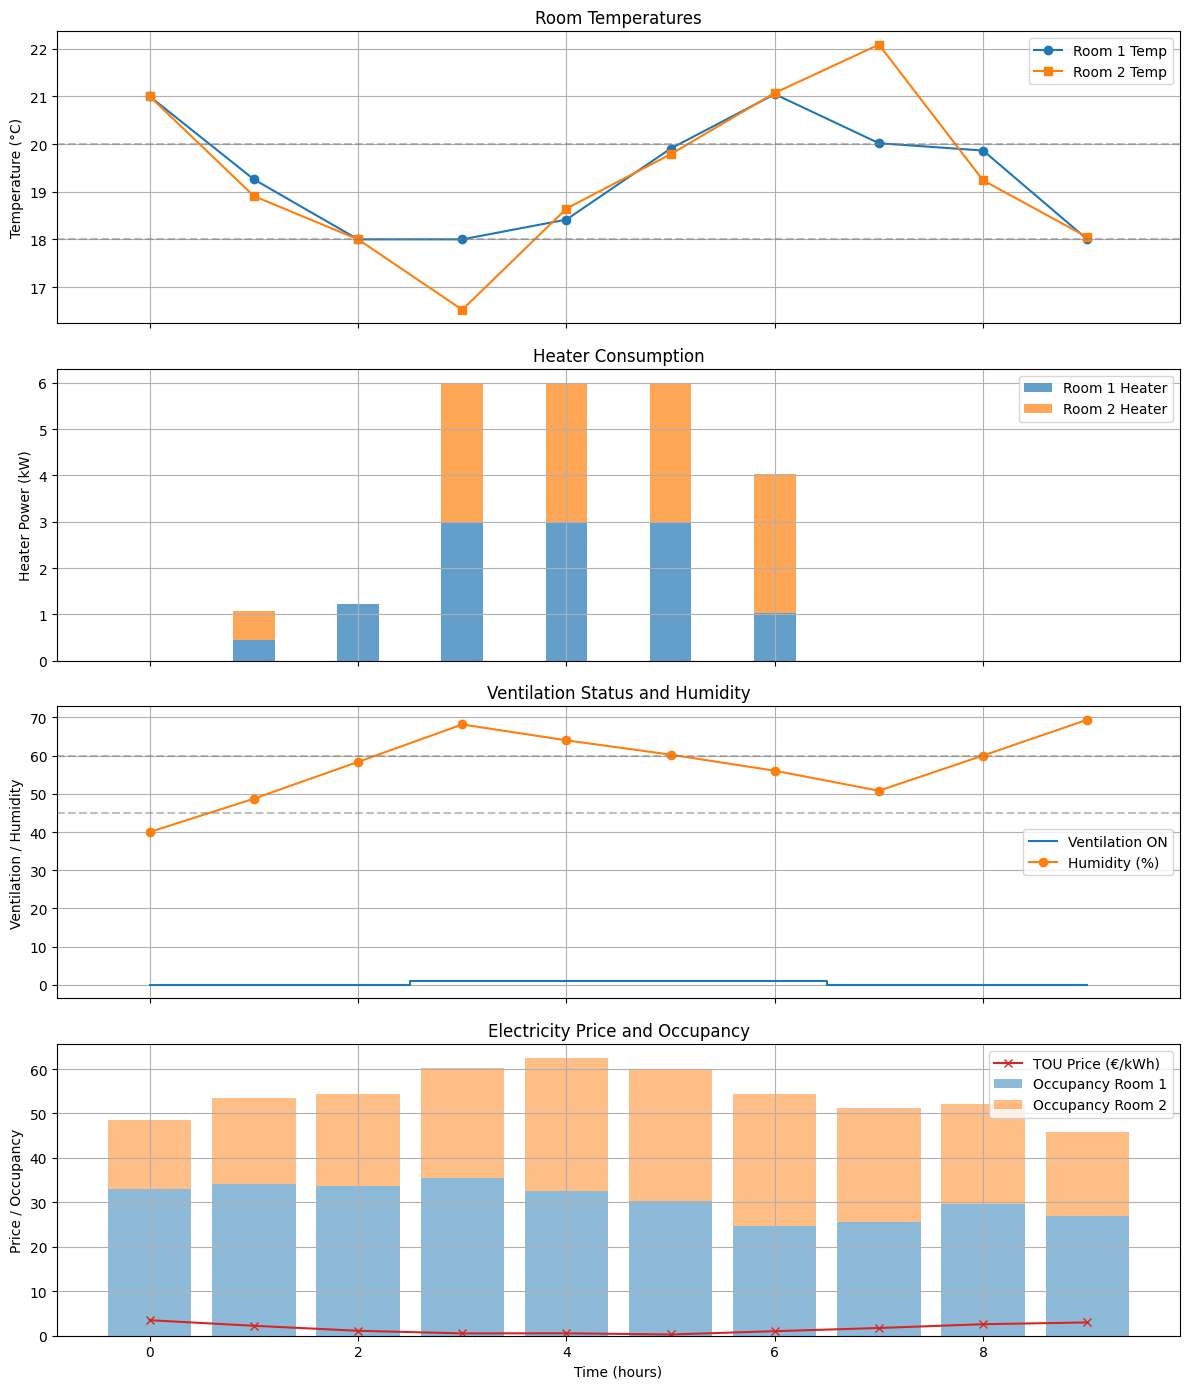

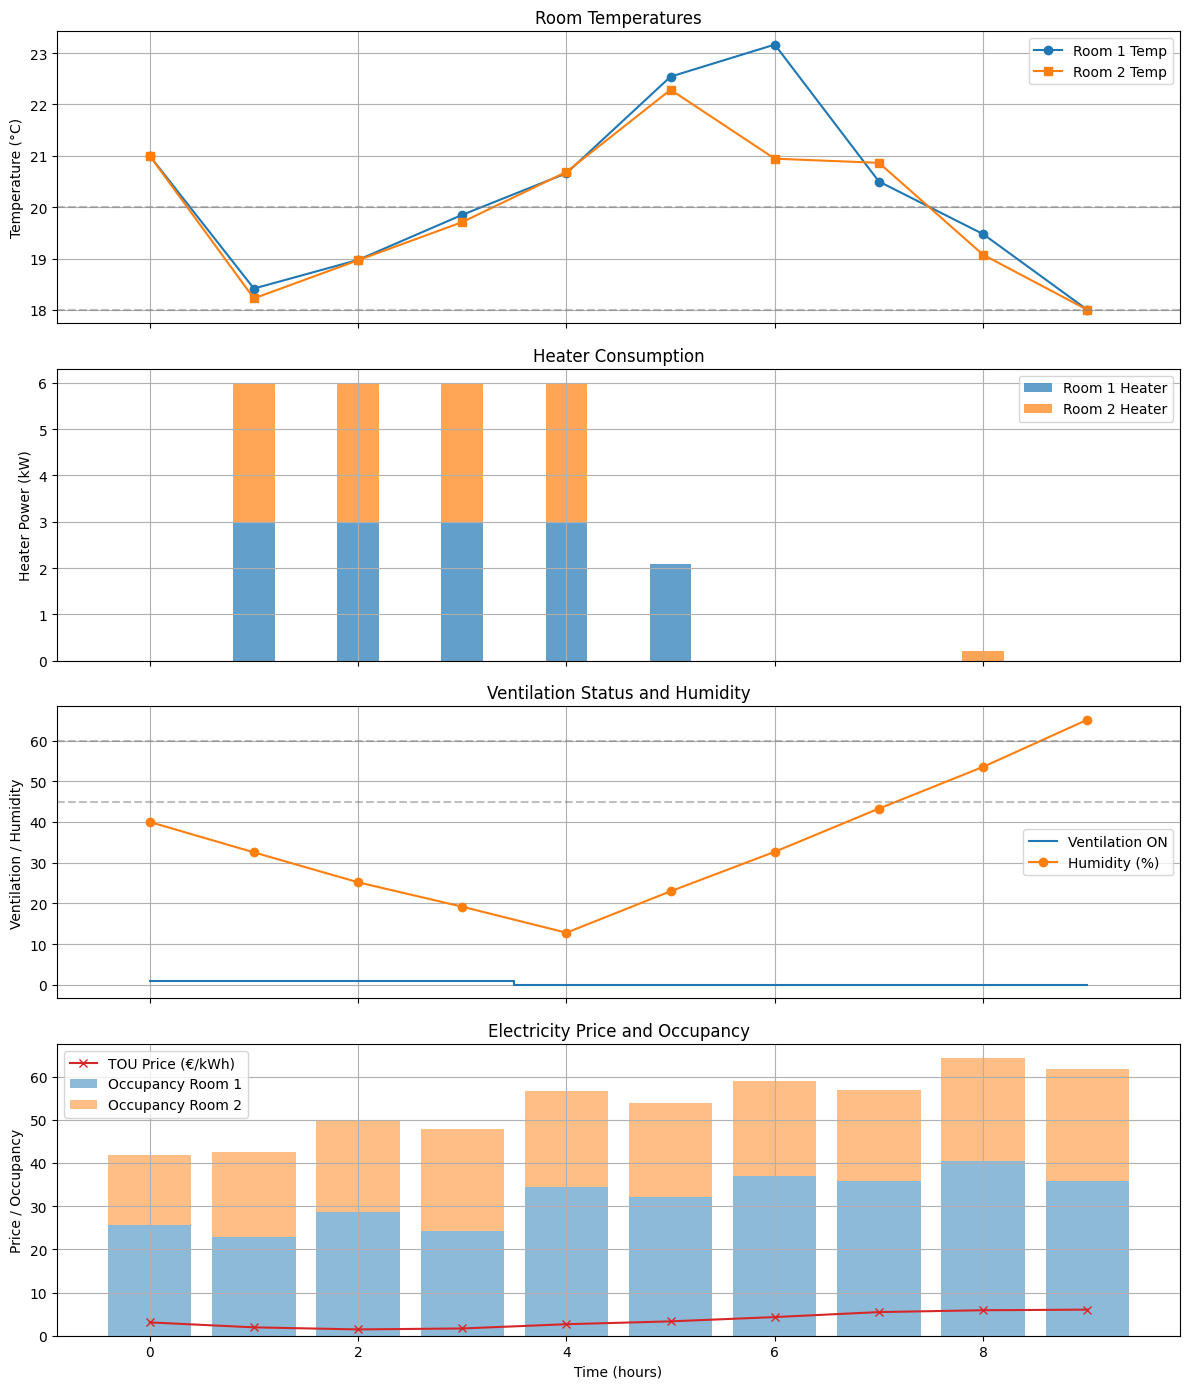

In [7]:
from PlotsRestaurant import plot_HVAC_results
dayA = 0
dayB = 1

HVAC_resA = all_results[dayA]
HVAC_resB = all_results[dayB]

plot_HVAC_results(HVAC_resA)
plot_HVAC_results(HVAC_resB)

